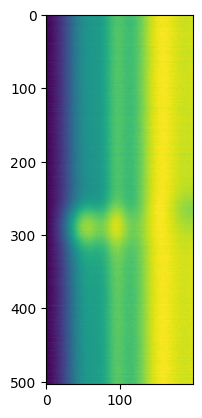

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
import pickle
import matplotlib.pyplot as plt
from matplotlib import cm
#from networks.NNModels import build_2D_cnn
import numpy as np
#from sys import argv
#from datetime import datetime

##file inputs - num_files, validation_percentage


features_dict = {
    'xsw_curve': tf.io.FixedLenFeature(shape = (504, 200, 1), dtype = tf.float32),
    #'cs_norm': tf.io.FixedLenFeature(shape = (46, 1), dtype = tf.float32),
    #'one_hot_count': tf.io.FixedLenFeature(shape = (6, 1), dtype=tf.float32)
}

filenames = ["Y:/3PeakC1sData/10000records1.tfrecords", "Y:/3PeakC1sData/10000records2.tfrecords"]

file = tf.data.Dataset.from_tensor_slices(filenames)
dataset = file.interleave(lambda filename: tf.data.TFRecordDataset(filename))
dataset = dataset.map(map_func = lambda serialized: tf.io.parse_single_example(serialized=serialized, features = features_dict))

dataset = dataset.map(map_func = lambda features:
                                features['xsw_curve'],
                                
                               )

spectrum = next(dataset.as_numpy_iterator())
spectrum = spectrum.reshape(504, 200)

#ax = plt.axes(projection='3d')

#x = np.linspace(0, 1, 200)
#z = np.linspace(0, 1, 504)
#X, Z = np.meshgrid(x, z)
#ax.plot_surface(X, Z, spectrum, vmin= spectrum.min() * 2, cmap=cm.Blues)
#ax.set_axis_off()

plt.imshow(spectrum)
    
